In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# def plot_grouped_results(x_labels, bar_data, colors=None, ylim=(0, 100), 
#                          xlabel='Step', ylabel='Similarity', figsize=(6, 5), n_groups=0, save_path=""):
#     """
#     Plot grouped results with semi-transparent data points showing distribution
#     and connecting lines for same targets across groups.
    
#     Parameters:
#     - x_labels: List of labels for the x-axis
#     - bar_data: List of lists containing the results for each group
#     - colors: List of colors for each bar (optional)
#     - ylim: Tuple specifying y-axis limits (default: (0.4, 1.0))
#     - xlabel: Label for x-axis (default: 'Step')
#     - ylabel: Label for y-axis (default: 'Similarity')
#     - figsize: Figure size (default: (8, 6))
#     """
#     # Calculate statistics
#     means = [np.mean(group) for group in bar_data]
    
#     # Set default colors if not provided
#     if colors is None:
#         colors = ['#e5a383', '#d45455', '#6a2a2b', '#b83f5b', '#f5768d']
    
#     # Create figure
#     fig, ax = plt.subplots(figsize=figsize)
    
#     # Plot bars
#     bars = ax.bar(x_labels, means, color=colors[:len(x_labels)], width=0.6, alpha=0.7)
    
#     # First plot individual data points with jitter and transparency
#     all_points = []
#     for i, group in enumerate(bar_data):
#         # Add jitter to x-position
#         x_jitter = np.random.normal(i, 0.05, size=len(group))
#         points = ax.scatter(x_jitter, group, color=colors[i], alpha=0.4, s=100, edgecolor='none')
#         all_points.append((x_jitter, group))
    
#     # Connect points from the same target across groups with gray lines
#     # Assuming each group has the same number of points (one per target)
#     num_targets = len(bar_data[0])
#     for target_idx in range(num_targets):
#         # Get the x and y coordinates for this target across all groups
#         x_coords = [all_points[group_idx][0][target_idx] for group_idx in range(len(bar_data))]
#         y_coords = [all_points[group_idx][1][target_idx] for group_idx in range(len(bar_data))]
#         ax.plot(x_coords, y_coords, color='gray', alpha=0.3, linewidth=1, linestyle='-')
    
#     # Add horizontal dashed line at first bar's y-value
#     stim_baseline = means[0]
#     ax.axhline(y=stim_baseline, color='black', linestyle='--', linewidth=3)
    
#     # Modify y-ticks to show percentages (multiplied by 100)
#     yticks = ax.get_yticks()
#     ax.set_yticklabels([f'{int(y)}' for y in yticks], fontsize=20)
    
#     # Set y-axis limits (still in original scale, but labels show *100)
#     # plt.ylim(*ylim)
#     # plt.ylim(40, 100)
    
#     # Add label for the dashed line (now using the original y-scale)
#     ax.text(0.02, stim_baseline + 0.01, 'Stim. baseline', 
#             transform=ax.get_yaxis_transform(), 
#             fontsize=20, color='black', va='bottom')
    
#     plt.xticks(fontsize=13)
    
#     # Remove right and top spines
#     ax.spines['right'].set_visible(False)
#     ax.spines['top'].set_visible(False)
    
#     # Add "T=10 epochs" label in upper right corner
#     # ax.text(0.88, 0.92, f'N={n_groups} groups', 
#     #         transform=ax.transAxes,
#     #         fontsize=20, color='black',
#     #         ha='right', va='top')
    
#     # Add labels
    
#     plt.ylabel(ylabel, fontsize=25)
    
#     plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')

#     # Adjust layout and show
    
#     plt.show()
#     return fig, ax

In [14]:
def plot_grouped_results(x_labels, bar_data, colors=None, ylim=(0, 100), 
                         xlabel='Step', ylabel='Similarity', figsize=(6, 5), n_groups=0, save_path=""):
    """
    Plot grouped results with semi-transparent data points showing distribution
    and connecting lines for same targets across groups.
    
    Parameters:
    - x_labels: List of labels for the x-axis
    - bar_data: List of lists containing the results for each group
    - colors: List of colors for each bar (optional)
    - ylim: Tuple specifying y-axis limits (default: (0.4, 1.0))
    - xlabel: Label for x-axis (default: 'Step')
    - ylabel: Label for y-axis (default: 'Similarity')
    - figsize: Figure size (default: (8, 6))
    """
    N = len(x_labels)  # Number of groups/bars
    
    # Create gradient colormap if colors not provided
    if colors is None:
        cmap = LinearSegmentedColormap.from_list("gradients", ["#D0E4F7", "#2E3A87"])  # Blue gradient
        colors = [cmap(i / (N - 1)) for i in range(N)]  # Generate N colors from the gradient
    
    # Calculate statistics
    means = [np.mean(group) for group in bar_data]
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot bars with gradient colors
    bars = ax.bar(x_labels, means, color=colors, width=0.6, alpha=0.7)
    
    # First plot individual data points with jitter and transparency
    all_points = []
    for i, group in enumerate(bar_data):
        # Add jitter to x-position
        x_jitter = np.random.normal(i, 0.05, size=len(group))
        points = ax.scatter(x_jitter, group, color=colors[i], alpha=0.4, s=100, edgecolor='none')
        all_points.append((x_jitter, group))
    
    # Connect points from the same target across groups with gray lines
    # Assuming each group has the same number of points (one per target)
    num_targets = len(bar_data[0])
    for target_idx in range(num_targets):
        # Get the x and y coordinates for this target across all groups
        x_coords = [all_points[group_idx][0][target_idx] for group_idx in range(len(bar_data))]
        y_coords = [all_points[group_idx][1][target_idx] for group_idx in range(len(bar_data))]
        ax.plot(x_coords, y_coords, color='gray', alpha=0.3, linewidth=1, linestyle='-')
    
    # Add horizontal dashed line at first bar's y-value
    stim_baseline = means[0]
    ax.axhline(y=stim_baseline, color='black', linestyle='--', linewidth=3)
    
    # Modify y-ticks to show percentages (multiplied by 100)
    yticks = ax.get_yticks()
    ax.set_yticklabels([f'{int(y)}' for y in yticks], fontsize=20)
    
    # Add label for the dashed line (now using the original y-scale)
    ax.text(0.02, stim_baseline + 0.01, 'Stim. baseline', 
            transform=ax.get_yaxis_transform(), 
            fontsize=20, color='black', va='bottom')
    
    plt.xticks(fontsize=13)
    
    # Remove right and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Add labels
    plt.ylabel(ylabel, fontsize=25)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()
    return fig, ax

In [15]:
bar = [
    [0.5425649881362915, 0.7451030015945435, 0.8286870718002319, 0.5797087550163269, 0.5797087550163269],
    [0.8788900375366211, 0.9146568179130554, 0.9026715159416199, 0.9286903142929077, 0.8948947787284851],
    [0.9065030813217163, 0.9146568179130554, 0.9026715159416199, 0.9286903142929077, 0.8948947787284851],
    [0.926695704460144, 0.9696734547615051, 0.9689272046089172, 0.9286903142929077, 0.9229402542114258],
    [0.974089503288269, 0.974089503288269, 0.974089503288269, 0.974089503288269, 0.9815637469291687]
]


In [16]:
bar = np.asarray(bar)

In [17]:
# # Example usage:
# if __name__ == "__main__":


    
#     # colors = ['#e5a383', '#d45455', '#6a2a2b', '#b83f5b', '#f5768d']
#     # colors = ['#83a3e5', '#5454d4', '#2a2a6a', '#3f5bb8', '#768df5']
#     colors = ['#83a3e5', '#768df5', '#5454d4', '#3f5bb8', '#2a2a6a']
    
#     x_labels = ['random', 'Step-1', 'Step-2', 'Step-2-last', 'Step-last']
    
#     fig, ax = plot_grouped_results(x_labels, xlabel='', ylabel='Similarity Score (%)', bar_data=bar*100, 
#                                    colors=colors, 
#                                    ylim=(0, 100), 
#                                    save_path="/home/ldy/Closed_loop_optimizing/plots/Interactive_search/interactive_searching_bar_performance.png")
    

/tmp/ipykernel_3013099/3933741390.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(y)}' for y in yticks], fontsize=20)


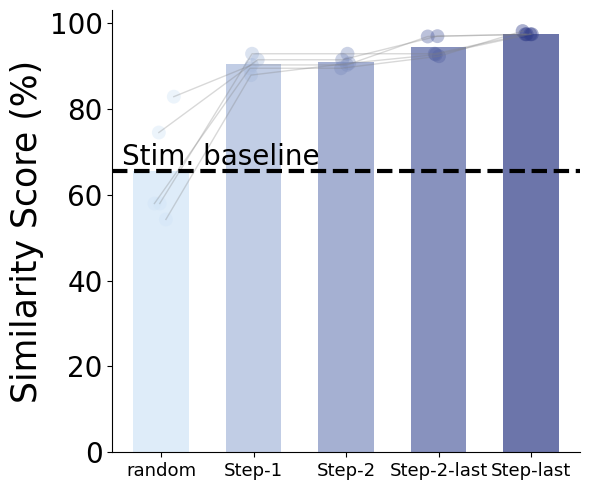

In [18]:

from matplotlib.colors import LinearSegmentedColormap

# Example usage:
if __name__ == "__main__":

    
    x_labels = ['random', 'Step-1', 'Step-2', 'Step-2-last', 'Step-last']
    
    fig, ax = plot_grouped_results(x_labels, ylabel='Similarity Score (%)', bar_data=bar*100, 
                                   colors=None, 
                                   ylim=(0, 100), 
                                   save_path="/home/ldy/Closed_loop_optimizing/plots/Interactive_search/interactive_searching_bar_performance.png")
    